# Paper outputs (MLST)

Creates all values, tables and figures used in the manuscript under `iop_mlst/`. The notebook only reads results, data and models from the source directories and never writes back to them. All outputs are English and locale-neutral, so the dissertation exports stay untouched.

Outputs go to `iop_mlst/generated/` and are included in the preamble of `iopjournal.tex`.

## Paths

The repository root is found as the nearest parent directory containing `pyproject.toml`, so the notebook runs from any location. The simulator sources of the pyTEP fork are expected next to the repository (`../pytep/pytep/simulator`) unless `PYTEP_SIMULATOR_DIR` is set.

In [12]:
import os
from pathlib import Path

base_dir = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
results_dir = base_dir / "results"
paper_dir = base_dir / "iop_mlst"
generated_dir = paper_dir / "generated"
simulator_dir = Path(os.environ.get("PYTEP_SIMULATOR_DIR",
                                    base_dir.parent / "pytep" / "pytep" / "simulator"))

generated_dir.mkdir(exist_ok=True)
base_dir, simulator_dir

(WindowsPath('c:/git/process_optimization_concept_drift'),
 WindowsPath('c:/git/pytep/pytep/simulator'))

## IDV(29) parameters

Two sources carry the parameters of the drift.

- The `#define`s in `temexd_mod.c` and `drift_function.c` fix segment duration, boundary shift, seed and the value range of $c(t)$. They are parsed from the C sources instead of being repeated here, since the simulator compiles exactly these values.
- `results/tep_generation.json` holds the drift coefficient $\kappa_m$ the stored run was generated with, together with the resulting peak calibration error.

In [13]:
import json
import re


def read_defines(path):
    pattern = re.compile(r"^#define\s+(\w+)\s+([-+0-9.eE]+)(?:ULL)?\b", re.MULTILINE)
    return {name: float(value) for name, value in pattern.findall(path.read_text(encoding="latin-1"))}


defines = {**read_defines(simulator_dir / "temexd_mod.c"),
           **read_defines(simulator_dir / "drift_function.c")}
generation = json.loads((results_dir / "tep_generation.json").read_text(encoding="utf-8"))
drift_amplitude = generation["drift_amplitude"]

assert drift_amplitude["idv"] == 29
{key: defines[key] for key in ("DRIFT_PERIOD", "DRIFT_GAMMA", "DRIFT_SEED", "CD_MID", "CD_HALF")}

{'DRIFT_PERIOD': 1752.0,
 'DRIFT_GAMMA': 0.2,
 'DRIFT_SEED': 42.0,
 'CD_MID': 0.0,
 'CD_HALF': 0.5}

The bands follow `drift_function.c`: the start level is drawn from the upper half of the value range without its inner quarter, the target level from the lower half accordingly.

In [14]:
cd_mid, cd_half = defines["CD_MID"], defines["CD_HALF"]
upper_band = (cd_mid + cd_half / 4, cd_mid + cd_half)
lower_band = (cd_mid - cd_half, cd_mid - cd_half / 4)
upper_band, lower_band

((0.125, 0.5), (-0.5, -0.125))

## Export

Numbers are written as `\num{}`/`\SI{}{}` with a decimal point, so siunitx sets them according to the paper's locale. Macro names carry the prefix `idv`.

In [15]:
from src.utils.latex_export import MacroExport

HOURS_PER_DAY = 24

def num(value, nd=None):
    text = f"{value:g}" if nd is None else f"{value:.{nd}f}"
    return rf"\num{{{text}}}"


def quantity(value, unit, nd=None):
    text = f"{value:g}" if nd is None else f"{value:.{nd}f}"
    return rf"\SI{{{text}}}{{{unit}}}"


macros = (MacroExport("generated by paper_outputs.ipynb - do not edit")
          .comment("IDV(29): parameters from temexd_mod.c, drift_function.c and results/tep_generation.json")
          .integer("idvIndex", drift_amplitude["idv"])
          .raw("idvDriftCoefficient", num(drift_amplitude["amp"]))
          .raw("idvSegmentDuration", quantity(defines["DRIFT_PERIOD"] / HOURS_PER_DAY, r"\day"))
          .raw("idvShiftFraction", num(defines["DRIFT_GAMMA"]))
          .integer("idvSeed", defines["DRIFT_SEED"])
          .raw("idvUpperBandLow", num(upper_band[0]))
          .raw("idvUpperBandHigh", num(upper_band[1]))
          .raw("idvLowerBandLow", num(lower_band[0]))
          .raw("idvLowerBandHigh", num(lower_band[1]))
          .raw("idvPeakErrorPercent", quantity(drift_amplitude["peak_pct"], r"\percent", 1))
          .raw("idvPeakErrorKelvin", quantity(drift_amplitude["peak_k"], r"\kelvin", 1)))

output = generated_dir / "tep_values.tex"
output.write_text(macros.render(), encoding="utf-8")
print(macros.render())

% generated by paper_outputs.ipynb - do not edit

% IDV(29): parameters from temexd_mod.c, drift_function.c and results/tep_generation.json
\newcommand{\idvIndex}{29}
\newcommand{\idvDriftCoefficient}{\num{0.3}}
\newcommand{\idvSegmentDuration}{\SI{73}{\day}}
\newcommand{\idvShiftFraction}{\num{0.2}}
\newcommand{\idvSeed}{42}
\newcommand{\idvUpperBandLow}{\num{0.125}}
\newcommand{\idvUpperBandHigh}{\num{0.5}}
\newcommand{\idvLowerBandLow}{\num{-0.5}}
\newcommand{\idvLowerBandHigh}{\num{-0.125}}
\newcommand{\idvPeakErrorPercent}{\SI{14.7}{\percent}}
\newcommand{\idvPeakErrorKelvin}{\SI{8.8}{\kelvin}}



## Figure: drift signal

The drift signal is taken from the recorded fault run instead of being evaluated from the C source, so the figure shows exactly the drift contained in the dataset. `driftf` is the ratio of the recorded stripper temperature in the fault run to that in the nominal run over the same sequence of operating points (column added in `tep_generation`), hence $c(t) = (\texttt{driftf} - 1)/\kappa_m$.

The run id comes from the provenance of `results/tep_generation.json`, so figure and table refer to the same run. The data were written in `.venv_tep` and are only read here (`rename=False`).

Segment boundaries are the upward jumps of `drift_segment`. The jump at activation, right at the start of the run, is excluded via `ACTIVATION_TOLERANCE_H`.

In [16]:
import numpy as np
import pandas as pd
from src.utils import run_registry as rr

data_store = rr.tep_data_store(base_dir / "data" / "tep")
error_data = data_store.load("data_error", run_id=generation["_provenance"]["id"], rename=False)

ACTIVATION_TOLERANCE_H = 1.0

kappa = drift_amplitude["amp"]
drift = pd.DataFrame({"time": error_data["time"].to_numpy(dtype=float),
                      "c": (error_data["driftf"].to_numpy(dtype=float) - 1.0) / kappa,
                      "segment": error_data["drift_segment"].to_numpy(dtype=int)})
assert drift["time"].is_monotonic_increasing
jumps = drift.loc[drift["segment"].diff() > 0, "time"].to_numpy()
boundaries = jumps[jumps > drift["time"].iloc[0] + ACTIVATION_TOLERANCE_H]
print(f"{len(boundaries) + 1} segments, boundaries at", boundaries.round(0))


11 segments, boundaries at [ 1694.  3653.  5390.  7018.  8623. 10581. 12216. 14003. 15614. 17414.]


Two panels at text width (153 mm, `iopjournal.cls`). The upper panel shows the whole run, the lower one the first `ZOOM_SEGMENTS` segments, whose range is shaded above. The bands of the start and target levels are shaded in both. Text is set by the document via PGF (`pgf.rcfonts = False`), so the figure uses the paper's font and needs `\usepackage{pgf}` in the preamble.

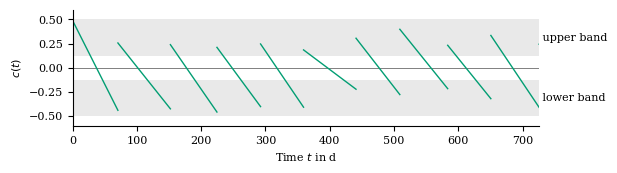

In [17]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

TEXTWIDTH_IN = 153 / 25.4
FONT_PT = 8
STRIDE = 10
HOURS_PER_DAY = 24

mpl.rcParams.update({
    "pgf.texsystem": "xelatex", "pgf.rcfonts": False,
    "font.family": "serif", "font.size": FONT_PT,
    "axes.labelsize": FONT_PT, "xtick.labelsize": FONT_PT, "ytick.labelsize": FONT_PT,
    "axes.spines.top": False, "axes.spines.right": False,
})

pieces = drift.iloc[::STRIDE].groupby("segment")[["time", "c"]]
gap = pd.DataFrame({"time": [np.nan], "c": [np.nan]})
piecewise = pd.concat([part for _, frame in pieces for part in (frame, gap)], ignore_index=True)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 0.25 * TEXTWIDTH_IN))
for band in (upper_band, lower_band):
    ax.axhspan(*band, color=ts.C["box"], alpha=0.12, lw=0)
ax.axhline(0.0, color=ts.C["box"], lw=0.5)
ax.plot(piecewise["time"] / HOURS_PER_DAY, piecewise["c"], **ts.line("drift_signal", lw=1.0, alpha=1.0))
t_end = drift["time"].iloc[-1] / HOURS_PER_DAY
ax.text(t_end, np.mean(upper_band), " upper band", va="center", ha="left")
ax.text(t_end, np.mean(lower_band), " lower band", va="center", ha="left")
ax.set_xlim(0.0, t_end)
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel("Time $t$ in d")
ax.set_ylabel("$c(t)$")

figures_dir = paper_dir / "figures"
figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / "drift_signal.pgf", bbox_inches="tight")
plt.show()